I want to try a different network strucutre where for one store it makes an easy choice

In [1]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor

In [ ]:
class thread_net(nn.Module):

    @staticmethod
    def _mlp(sizes: list[int]) -> nn.Sequential:
        """Linear layers with ReLU between; no ReLU after the last linear."""
        if len(sizes) < 2:
            raise ValueError("layer_list needs at least [input_dim, output_dim]")
        layers: list[nn.Module] = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    def __init__(self, layer_list=[12, 40, 40, 40, 1], num_nets=500):
        super().__init__()
        self.layer_list = list(layer_list)
        self.nets = nn.ModuleList(
            [self._mlp(self.layer_list) for _ in range(num_nets)]
        )
        self.num_nets = num_nets

    def forward(self, x):
        return torch.stack([net(x[i::self.num_nets]) for i, net in enumerate(self.nets)], dim=0)

In [4]:
all_specs = [
    "7_day_rolling_ema",	
    "7_day_rolling_mean",	
    "30_day_rolling_ema",	
    "diff_180_day",	
    "diff_90_day",	
    "30_day_rolling_mean",	
    "diff_30_day",	
    "7_day_rolling_min",	
    "7_day_lag",	
    "30_day_rolling_min",	
    "14_day_lag",	
    "diff_365_day",	
]

In [5]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True
    )

In [6]:
h_cost = 1
l_cost = 3

num_nets = train_loader.dataset.y.shape[1]
in_per_net = train_loader.dataset.x.shape[1] // num_nets
assert train_loader.dataset.x.shape[1] == in_per_net * num_nets
layer_list = [in_per_net, 40, 40, 40, 1]  # any length >= 2, e.g. [in_per_net, 128, 64, 1]
net = thread_net(layer_list=layer_list, num_nets=num_nets)
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
loss_tensor = partial(pinball_loss_tensor, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

train_losses, val_losses = train(net, optimizer, loss, train_loader, val_loader, epochs=200, eval_interval=10, device="cpu")

test_loss = get_test_loss(net, test_loader, loss, "cpu")

Training: 100%|██████████| 200/200 [01:39<00:00,  2.01step/s, train_loss=10.2583]                  


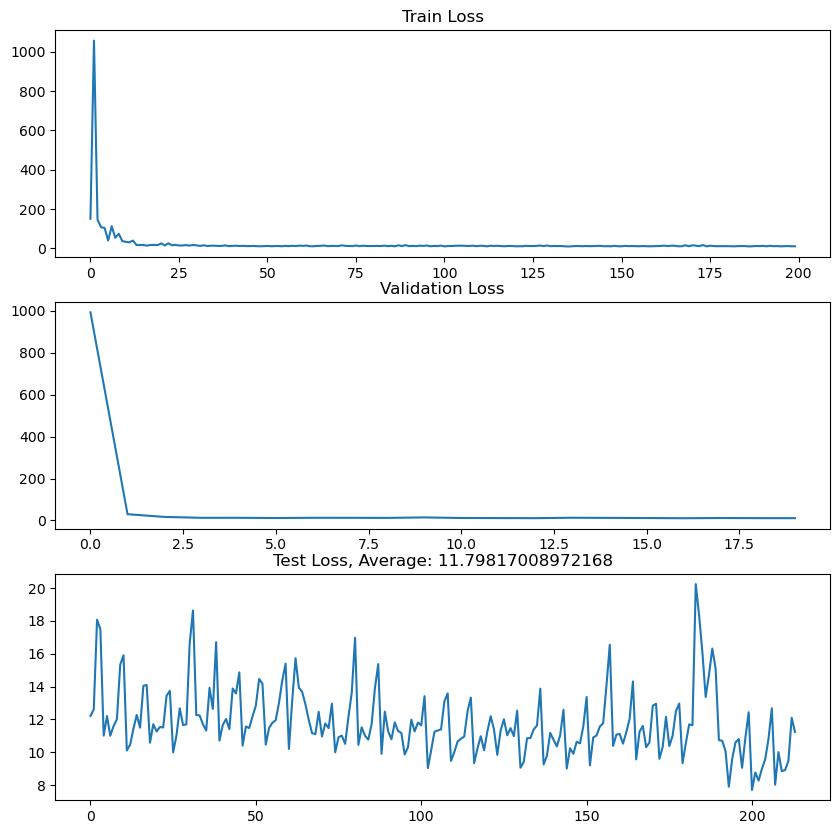

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()

In [8]:
test_data = test_loader.dataset.x
test_y = test_loader.dataset.y
test_y_hat = net(test_data)
test_loss_tensor = loss_tensor(test_y_hat, test_y)



In [9]:
xcols = test_loader.dataset.x_columns
with open('x_columns.txt', 'w') as f:
    for col in xcols:
        f.write(f"{col}\n")

In [10]:
print(test_loader.dataset.y_columns)

['store_1_item_1', 'store_1_item_2', 'store_1_item_3', 'store_1_item_4', 'store_1_item_5', 'store_1_item_6', 'store_1_item_7', 'store_1_item_8', 'store_1_item_9', 'store_1_item_10', 'store_1_item_11', 'store_1_item_12', 'store_1_item_13', 'store_1_item_14', 'store_1_item_15', 'store_1_item_16', 'store_1_item_17', 'store_1_item_18', 'store_1_item_19', 'store_1_item_20', 'store_1_item_21', 'store_1_item_22', 'store_1_item_23', 'store_1_item_24', 'store_1_item_25', 'store_1_item_26', 'store_1_item_27', 'store_1_item_28', 'store_1_item_29', 'store_1_item_30', 'store_1_item_31', 'store_1_item_32', 'store_1_item_33', 'store_1_item_34', 'store_1_item_35', 'store_1_item_36', 'store_1_item_37', 'store_1_item_38', 'store_1_item_39', 'store_1_item_40', 'store_1_item_41', 'store_1_item_42', 'store_1_item_43', 'store_1_item_44', 'store_1_item_45', 'store_1_item_46', 'store_1_item_47', 'store_1_item_48', 'store_1_item_49', 'store_1_item_50', 'store_2_item_1', 'store_2_item_2', 'store_2_item_3', 'sto

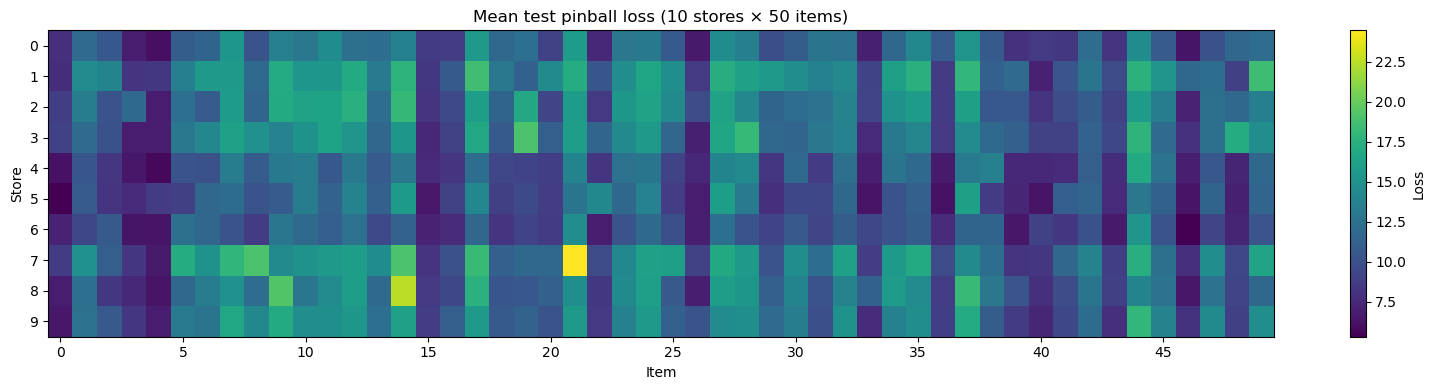

In [11]:
import numpy as np

# Per (store, item) mean pinball loss over test rows; columns are store-major: store_1_item_1…store_1_item_50, …
loss_per_col = test_loss_tensor.mean(dim=0).detach().cpu().numpy()
n_stores, n_items = 10, 50
loss_matrix = loss_per_col.reshape(n_stores, n_items)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(loss_matrix, aspect="auto", cmap="viridis")
ax.set_xlabel("Item")
ax.set_ylabel("Store")
ax.set_title("Mean test pinball loss (10 stores × 50 items)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Loss")
ax.set_xticks(np.arange(0, n_items, 5))
ax.set_yticks(np.arange(n_stores))
plt.tight_layout()
plt.show()

In [12]:
# Mean test pinball loss per target column, greatest to least
ranked = sorted(
    zip(test_loader.dataset.y_columns, loss_per_col),
    key=lambda t: t[1],
    reverse=True,
)
for col, loss_val in ranked:
    print(col, loss_val)


store_8_item_22 24.468086
store_9_item_15 22.4954
store_9_item_10 19.284689
store_8_item_9 19.044039
store_4_item_20 19.015715
store_8_item_15 19.006315
store_2_item_18 18.618647
store_2_item_50 18.531147
store_8_item_18 18.312729
store_9_item_38 18.262129
store_4_item_29 18.131615
store_3_item_15 18.043129
store_2_item_38 18.022905
store_10_item_45 17.987576
store_8_item_8 17.943666
store_4_item_45 17.759233
store_2_item_15 17.672455
store_2_item_45 17.625149
store_9_item_18 17.527283
store_2_item_36 17.499601
store_3_item_13 17.440426
store_8_item_45 17.28214
store_2_item_28 17.25684
store_4_item_49 17.162806
store_8_item_6 17.160465
store_2_item_22 17.133675
store_10_item_38 17.080765
store_2_item_10 17.077143
store_8_item_36 17.053358
store_10_item_10 17.050434
store_2_item_13 17.033945
store_3_item_10 17.00589
store_5_item_45 16.983244
store_8_item_28 16.954126
store_3_item_20 16.881788
store_10_item_8 16.794872
store_4_item_18 16.794867
store_2_item_25 16.62345
store_4_item_28 16